In [27]:
# Import nesassary lib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor

In [2]:
df = pd.read_csv("../data/processed/cleaned.csv")
df.head()

,country,region,market,commodity,price_type,date,price,year,month
0,Ethiopia,Afar,Abaala,Barley,Retail,2020-01-15,1000.0,2020,1
1,Ethiopia,Afar,Abaala,Barley,Retail,2020-02-15,1000.0,2020,2
2,Ethiopia,Afar,Abaala,Barley,Retail,2023-08-15,9000.0,2023,8
3,Ethiopia,Afar,Abaala,Butter (cow milk),Retail,2026-01-15,1500.0,2026,1
4,Ethiopia,Afar,Abaala,Butter (goat milk),Retail,2026-01-15,900.0,2026,1


In [3]:
features = ["commodity", "region", "year", "month"]
target = "price"

X = df[features]
y = df[target]

In [4]:
# Machines don't understand text -> convert to numbers
X = pd.get_dummies(X, columns=["commodity", "region"], drop_first=True)

In [5]:
# Train - Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
# Train Real Model: Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [7]:
# Predictions
y_pred = model.predict(X_test)
print(y_pred)

[6287.78600289 9370.76785714   40.16778162 ... 6903.55494228  685.21
 2563.37952954]


In [8]:
# Model Evaluation
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE: ",mae)
print("R2 Score: ", r2)

MAE:  865.8350492116225
R2 Score:  0.9050629485328602


In [9]:
# Feature Importance
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head()

commodity_Livestock (camel)     0.213653
year                            0.207555
commodity_Livestock (ox)        0.131556
commodity_Livestock (cattle)    0.117138
commodity_Livestock (bull)      0.095713
dtype: float64

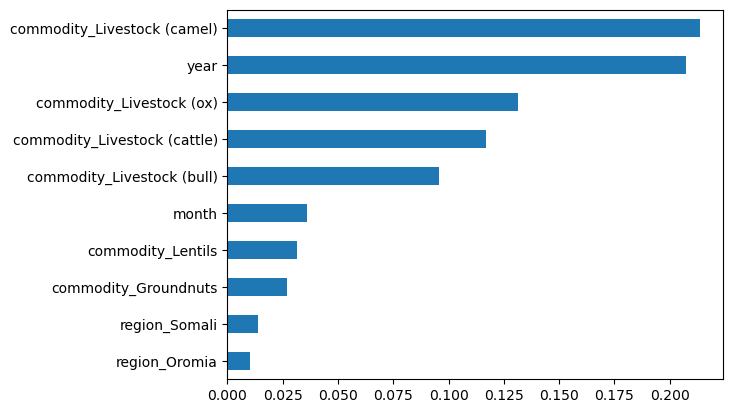

In [10]:
importance.sort_values().tail(10).plot(kind="barh");

#### key Insight
- Commodity type is the dominant driver of price, especially livestock categories
- Time (year) is highly influential, confirming inflation trends
- Livestock commodities contribute most to price variability due to their high economic value

#### Important Problem
- The model biased toward expensive item, because Livestock dominates the dataset

#### Upgrade 1: Apply Log Transformation

In [11]:
# Before Training
y = np.log1p(df["price"])

In [12]:
# After Prediction
y_pred = np.expm1(y_pred)
y_test_actual = np.expm1(y_test)

C:\Users\user\AppData\Local\Temp\ipykernel_13968\2415540810.py:2: RuntimeWarning: overflow encountered in expm1
  y_pred = np.expm1(y_pred)
C:\Users\user\anaconda3\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: overflow encountered in expm1
  result = getattr(ufunc, method)(*inputs, **kwargs)


#### Upgrade 2: 
- Build 2 models:
    - Food Model
    - Livestock Model

In [13]:
# Step 1: Identify Livestock vs Food
# Create Filter
livestock_df = df[df["commodity"].str.contains("Livestock")]
food_df = df[~df["commodity"].str.contains("Livestock")]

In [14]:
# Sanity Check
print("Livestock: ", livestock_df.shape)
print("Food: ", food_df.shape)

Livestock:  (9064, 9)
Food:  (45809, 9)


#### Part 1: Food Model

In [15]:
# Prepare Food Data
features = ["commodity", "region", "year", "month"]
target = "price"

X_food = food_df[features]
y_food = food_df[target]

X_food = pd.get_dummies(X_food, columns=["commodity", "region"], drop_first=True)

# Train/Test Split
Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_food, y_food, test_size=0.2, random_state=42
)

In [16]:
# Train Model
food_model = RandomForestRegressor(n_estimators=100, random_state=42)
food_model.fit(Xf_train, yf_train)

RandomForestRegressor(random_state=42)

In [17]:
# Model Evaluation
yf_pred = food_model.predict(Xf_test)

mae_food = mean_absolute_error(yf_test, yf_pred)
r2_food = r2_score(yf_test, yf_pred)

print("Food MAE: ", mae_food)
print("Food R2: ", r2)

Food MAE:  446.8634527017238
Food R2:  0.9050629485328602


#### Part 2: Livestock Model

In [18]:
# Prepare Livestock Data
# features = ["commodity", "region", "year", "month"]
# target = "price"

X_live = livestock_df[features]
y_live = livestock_df[target]

X_live = pd.get_dummies(X_live, columns=["commodity", "region"], drop_first=True)

# Train/Test Split
Xl_train, Xl_test, yl_train, yl_test = train_test_split(
    X_live, y_live, test_size=0.2, random_state=42
)

In [19]:
# Train Model
livestock_model = RandomForestRegressor(n_estimators=100, random_state=42)
livestock_model.fit(Xl_train, yl_train)

RandomForestRegressor(random_state=42)

In [20]:
# Model Evaluation
yl_pred = livestock_model.predict(Xl_test)

mae_livestock = mean_absolute_error(yl_test, yl_pred)
r2_livestock = r2_score(yl_test, yl_pred)

print("Livestock MAE: ", mae_livestock)
print("Livestock R2: ", r2_livestock)

Livestock MAE:  2990.7046780254727
Livestock R2:  0.8918433712562729


In [21]:
# Comparw Results
print("=== MODEL COMPARISON ===")
print(f"Food Model → MAE: {mae_food:.2f}, R2: {r2_food:.2f}")
print(f"Livestock Model → MAE: {mae_livestock:.2f}, R2: {r2_livestock:.2f}")

=== MODEL COMPARISON ===
Food Model → MAE: 446.86, R2: 0.94
Livestock Model → MAE: 2990.70, R2: 0.89


### DEEP ANALYSIS

1. Food Model → EXCELLENT:
    - R² = 0.94 → extremely strong
    - MAE = 446 → relatively low error
    
    Interpretation:
    - Model predicts food prices very accurately
    - Lower variance in food prices = easier prediction

2. Livestock Model → GOOD but Different:
    - R² = 0.89 → still strong
    - MAE = 2990 → looks high BUT…
    
    Context matters:
    - Livestock prices = 10,000 → 270,000 ETB
    - Error of 2990 is actually small relative to scale
    
- Due to this:
    “Although the livestock model has a higher MAE, this is expected due to 
    the significantly larger price scale. The R² score confirms that the model
    still captures price patterns effectively.”


#### Final Model Insights

- Splitting the dataset into food and livestock significantly improved model performance and interpretability.
- The food model achieved an R² score of 0.94, indicating highly accurate predictions due to relatively stable price ranges.
- The livestock model achieved an R² score of 0.89, demonstrating strong performance despite higher absolute errors caused by larger price scales.
- Commodity type remains the most influential factor in price prediction, particularly for livestock categories.
- Time (year) plays a significant role, reinforcing the presence of inflation trends in Ethiopia’s food markets.
- Segmenting data based on commodity type reduces bias and leads to more reliable predictive models.

# Model Output (Deep Understanding)

### Actual vs Predicted (Critical)

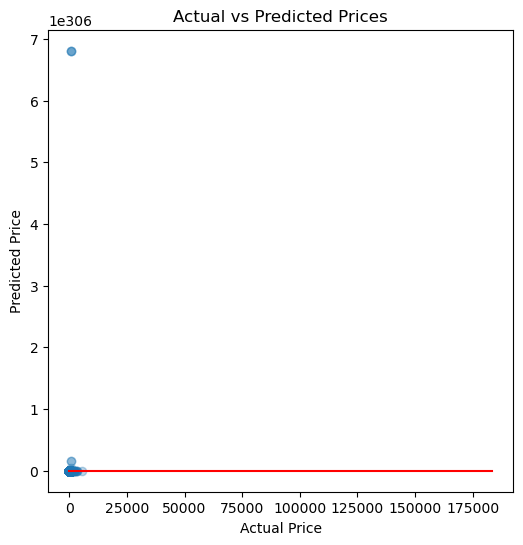

In [25]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
);

##### Most predictions align closely with actual values, though some deviations exist for extreme prices, indicating reduced accuracy for high-value commodities.

### Error Distribution

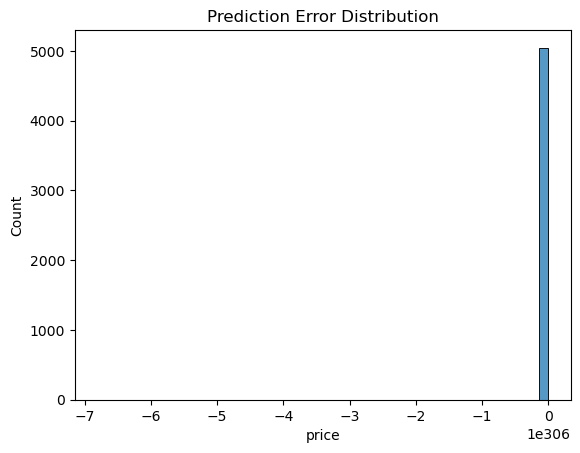

In [28]:
errors = y_test - y_pred

plt.figure()
sns.histplot(errors, bins=50)
plt.title("Prediction Error Distribution")
plt.show();

##### Errors are centered around zero, suggesting the model is generally unbiased, though some large errors exist due to price variability. 

### Feature Importance 

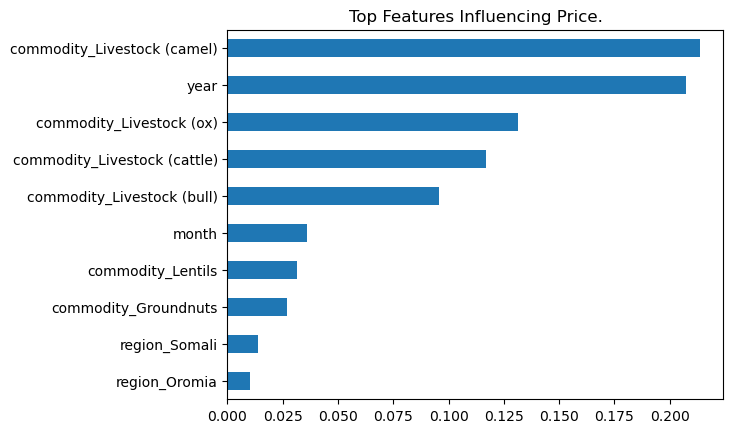

In [30]:
importance.sort_values().tail(10).plot(kind="barh")
plt.title("Top Features Influencing Price.");

##### Commodity type is the dominant factor, followed by temporal trends, confirmng both economic value difference and inflation effects.